# Model Training and Evaluation Report

This report replaces the single logistic-regression baseline with a four-family comparison (`dummy`, `logistic_regression`, `random_forest`, `xgboost`). Each tunable family is hyperparameter-searched and cross-validated on the **training data only**, scored by mean cross-validated **PR-AUC** — the appropriate metric under the ~6.6% fail-rate imbalance. The winner is the family with the highest CV PR-AUC, persisted to a stable `models/selected_model.joblib` artifact.

Selection never sees the test set. Each family's operating threshold is **frozen on pooled out-of-fold training predictions**, never tuned on test. The held-out test split is read exactly once, after the winner and its threshold are locked, to estimate generalization and to build a per-family comparison table at each family's frozen threshold.

On cross-validation the winner is **random_forest** (CV PR-AUC ≈ 0.227), ahead of xgboost (≈ 0.198) and logistic regression (≈ 0.180); `dummy` (≈ 0.066) marks the chance floor at the base fail rate.

## Analysis Inputs

The analysis uses the raw train/test splits, the per-family hyperparameter grids in `configs/model_config.yaml`, and the cost matrix in `configs/cost_config.yaml`. Training and selection run against `data/splits/train.csv` only; `data/splits/test.csv` is loaded once for the held-out comparison. Feature selection and imputation are not applied to these files — each model pipeline carries its own `SecomPreprocessor`, fit per cross-validation fold, so preprocessing never leaks across the split. Generated artifacts — per-family pipelines, the stable `selected_model.joblib`, `reports/model_comparison.{csv,json}`, and `reports/selected_model_metrics.json` — are written under `models/` and `reports/`, keeping the evaluation tied to the exact configuration and data split summarized below. The canonical `reports/cv_results.json` (with per-fold diagnostics) is produced by `scripts/train_models.py`, not by this report.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

sys.path.insert(0, "../src")

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

from yield_risk.config import load_config, load_cost_config, load_model_config
from yield_risk.evaluate import (
    compute_metrics,
    evaluate_at_threshold,
    format_report,
    save_metrics,
)
from yield_risk.importance import extract_feature_importance, plot_top_features
from yield_risk.model import (
    MODEL_REGISTRY,
    frozen_operating_threshold,
    model_feature_names,
    run_search,
    select_best,
)
from yield_risk.thresholding import threshold_cost_curve

ROOT = Path("..").resolve()

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

## Configuration

The configuration fixes the random seed, a 15% held-out test split, five cross-validation folds, and preprocessing filters for missingness, coefficient of variation, and correlation. The randomized search draws up to `search_n_iter` candidates per tunable family (capped at the grid size). The cost matrix assigns a false pass ten times the cost of a false fail, so threshold selection is evaluated against failure escapes rather than overall classification accuracy.

In [2]:
cfg = load_config(ROOT / "configs" / "config.yaml")
cost_cfg = load_cost_config(ROOT / "configs" / "cost_config.yaml")
model_cfg = load_model_config(ROOT / "configs" / "model_config.yaml")

splits_dir = ROOT / "data" / "splits"
models_dir = ROOT / "models"
reports_dir = ROOT / "reports"
figures_dir = reports_dir / "figures"

config_summary = pd.DataFrame(
    [
        ("random_seed", cfg.run.random_seed),
        ("test_size", cfg.run.test_size),
        ("cv_folds", cfg.run.cv_folds),
        ("missing_threshold", cfg.run.missing_threshold),
        ("cv_threshold", cfg.run.cv_threshold),
        ("correlation_threshold", cfg.run.correlation_threshold),
        ("search_n_iter", model_cfg["search"]["n_iter"]),
        ("false_fail_cost", cost_cfg.cost_matrix.false_fail),
        ("false_pass_cost", cost_cfg.cost_matrix.false_pass),
        ("threshold_low", cost_cfg.threshold_search.low),
        ("threshold_high", cost_cfg.threshold_search.high),
        ("threshold_steps", cost_cfg.threshold_search.steps),
    ],
    columns=["setting", "value"],
)
config_summary

,setting,value
0,random_seed,42.00
1,test_size,0.15
2,cv_folds,5.00
3,missing_threshold,0.10
4,cv_threshold,0.01
5,correlation_threshold,0.95
6,search_n_iter,20.00
7,false_fail_cost,1.00
8,false_pass_cost,10.00
9,threshold_low,0.01


The configured review is conservative in two ways: each family's quality is estimated by cross-validation before any family touches the test set, and the decision threshold is judged with an explicit false-pass penalty. This matters because the class balance is highly skewed toward passing wafers, so a single point estimate on the test set would be both noisy and prone to leakage if it drove model choice.

## Train/Test Population

The raw splits contain 1,331 training rows and 236 test rows across 590 raw sensor columns; the pipeline's `SecomPreprocessor` retains 242 of those columns after fold-wise filtering and imputation. Failure prevalence is nearly identical in both splits, with a 6.61% train fail rate and a 6.78% test fail rate, so the held-out test set is representative of the rare-failure regime seen during fitting.

In [3]:
train_path = ROOT / "data" / "splits" / "train.csv"
test_path = ROOT / "data" / "splits" / "test.csv"
missing_paths = [path for path in [train_path, test_path] if not path.exists()]
if missing_paths:
    raise FileNotFoundError(
        "Processed train/test data are required. Missing: "
        + ", ".join(str(path) for path in missing_paths)
    )

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sensor_cols = [column for column in train.columns if column.startswith("sensor_")]
if not sensor_cols:
    raise ValueError("No sensor_* columns found in processed training data.")

X_train = train[sensor_cols]
y_train = train["label"]
X_test = test[sensor_cols]
y_test = test["label"].to_numpy()

split_summary = pd.DataFrame(
    {
        "split": ["train", "test"],
        "rows": [len(train), len(test)],
        "fail_rate": [y_train.mean(), test["label"].mean()],
        "sensor_count": [len(sensor_cols), len(sensor_cols)],
    }
)
split_summary

,split,rows,fail_rate,sensor_count
0,train,1331,0.066116,590
1,test,236,0.067797,590


The low failure rate means a model can appear stable while missing most failures. The empirical interpretation therefore centers on ROC-AUC, PR-AUC, recall, false passes, and cost-sensitive threshold behavior.

## Cross-Validation Across Families

Each family is tuned and scored on the training split with stratified five-fold cross-validation, optimizing average precision (PR-AUC). Tunable families (`logistic_regression`, `random_forest`, `xgboost`) run a randomized hyperparameter search; `dummy` is scored directly as the chance floor. For XGBoost, `scale_pos_weight` is set from the training class ratio. Estimators run single-threaded and parallelism is applied only at the search level to avoid CPU oversubscription.

`random_forest` wins with a mean CV PR-AUC of 0.227 ± 0.078, ahead of `xgboost` (0.198 ± 0.063) and `logistic_regression` (0.180 ± 0.062). The wide standard-deviation bands reflect the rare-failure regime: with so few positives per fold, fold-to-fold PR-AUC is volatile, and the top two families overlap well within one standard deviation.

In [4]:
search_results = [
    run_search(
        name,
        X_train,
        y_train,
        model_cfg,
        cfg.run.cv_folds,
        cfg.run.random_seed,
        cfg.run.missing_threshold,
        cfg.run.cv_threshold,
        cfg.run.correlation_threshold,
    )
    for name in MODEL_REGISTRY
]

cv_summary = (
    pd.DataFrame(
        {
            "model": [r.name for r in search_results],
            "cv_pr_auc_mean": [r.cv_pr_auc_mean for r in search_results],
            "cv_pr_auc_std": [r.cv_pr_auc_std for r in search_results],
            "best_params": [r.best_params for r in search_results],
        }
    )
    .sort_values("cv_pr_auc_mean", ascending=False)
    .reset_index(drop=True)
)
cv_summary

,model,cv_pr_auc_mean,cv_pr_auc_std,best_params
0,random_forest,0.226585,0.078363,"{'classifier__n_estimators': 200, 'classifier_..."
1,xgboost,0.197751,0.062983,"{'classifier__subsample': 0.8, 'classifier__n_..."
2,logistic_regression,0.179721,0.061659,{'classifier__C': 0.001}
3,dummy,0.065982,0.001976,{}


In [5]:
winner = select_best(search_results)
winning = next(r for r in search_results if r.name == winner)

models_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)

for result in search_results:
    joblib.dump(result.estimator, models_dir / f"{result.name}.joblib")

selected_path = models_dir / "selected_model.joblib"
joblib.dump(winning.estimator, selected_path)

# Freeze each family's operating threshold on pooled out-of-fold train
# predictions — never on the test set — mirroring scripts/train_models.py.
# The canonical reports/cv_results.json (with per-fold diagnostics) is owned
# by scripts/train_models.py; this report only consumes the in-memory results.
frozen_thresholds = {
    result.name: frozen_operating_threshold(
        result.estimator,
        X_train,
        y_train,
        cfg.run.cv_folds,
        cfg.run.random_seed,
        cost_cfg.cost_matrix,
        cost_cfg.threshold_search,
    )
    for result in search_results
}

print(f"Selected winner by CV PR-AUC: {winner}")
print(f"Best params: {winning.best_params}")
print(f"Frozen threshold (train OOF): {frozen_thresholds[winner]:.3f}")
print(f"Saved {len(search_results)} per-family models and {selected_path.name} to {models_dir}")

Selected winner by CV PR-AUC: random_forest
Best params: {'classifier__n_estimators': 200, 'classifier__min_samples_leaf': 5, 'classifier__max_depth': 20}
Frozen threshold (train OOF): 0.140
Saved 4 per-family models and selected_model.joblib to C:\Users\Virgil\Code\semiconductor-yield-root-cause\models


Selection is fixed before test evaluation: the winner was chosen on cross-validated PR-AUC over the training split alone, and is persisted to the stable `selected_model.joblib`. Downstream consumers (feature importance, SHAP explanations, batch scoring) load that one path and never reference a specific family, so the choice of winner can change without any downstream edits. Cross-validation supports a modest modeling claim: the sensor set carries predictive information, but no family is strong enough for high-confidence automated disposition. Downstream explanations are useful for ranking sensors and prioritizing engineering review.

## Held-Out Comparison

Selection is fixed before test evaluation. Every family is scored on the held-out wafers at its **frozen** threshold — the cost-optimal operating point derived from pooled out-of-fold training predictions, not from the test set — and the resulting test metrics are joined to the CV PR-AUC that drove selection.

On test, the selected `random_forest` reaches ROC-AUC 0.793 and PR-AUC 0.222 at its frozen threshold of 0.14 (recall 0.81, expected cost 83). It also leads on cross-validation, so the same family tops both rankings; `xgboost` is the closest challenger (test PR-AUC 0.213, ROC-AUC 0.786, expected cost 114), as discussed at the end of this report.

In [6]:
comparison_rows = []
for result in search_results:
    fam_prob = result.estimator.predict_proba(X_test)[:, 1]
    fam_frozen = frozen_thresholds[result.name]
    fam_metrics, fam_cost = evaluate_at_threshold(
        y_test, fam_prob, fam_frozen, cost_cfg.cost_matrix
    )
    comparison_rows.append(
        {
            "model": result.name,
            "cv_pr_auc_mean": result.cv_pr_auc_mean,
            "test_pr_auc": fam_metrics.pr_auc,
            "test_roc_auc": fam_metrics.roc_auc,
            "test_recall": fam_metrics.recall,
            "test_precision": fam_metrics.precision,
            "frozen_threshold": fam_frozen,
            "expected_cost": fam_cost,
            "selected": result.name == winner,
        }
    )

comparison = pd.DataFrame(comparison_rows)
comparison.to_csv(reports_dir / "model_comparison.csv", index=False)
(reports_dir / "model_comparison.json").write_text(json.dumps(comparison_rows, indent=2))
comparison

,model,cv_pr_auc_mean,test_pr_auc,test_roc_auc,test_recall,test_precision,frozen_threshold,expected_cost,selected
0,dummy,0.065982,0.068367,0.503977,0.0625,0.076923,0.01,162.0,False
1,logistic_regression,0.179721,0.168193,0.725568,0.3125,0.142857,0.52,140.0,False
2,random_forest,0.226585,0.221624,0.792614,0.8125,0.196970,0.14,83.0,True
3,xgboost,0.197751,0.213262,0.785795,0.6250,0.156250,0.02,114.0,False


In [7]:
pipeline = winning.estimator
y_prob = pipeline.predict_proba(X_test)[:, 1]
frozen = frozen_thresholds[winner]
metrics, expected_cost = evaluate_at_threshold(
    y_test, y_prob, frozen, cost_cfg.cost_matrix
)
save_metrics(metrics, reports_dir / "selected_model_metrics.json")

print(format_report(metrics, winner))
print(
    f"\nFrozen threshold (train OOF): {frozen:.3f}; "
    f"expected cost: {expected_cost:.1f}"
)

cm = metrics.confusion_matrix
confusion_df = pd.DataFrame(
    cm,
    index=["Actual pass", "Actual fail"],
    columns=["Predicted pass", "Predicted fail"],
)
# confusion_matrix layout is [[TN, FP], [FN, TP]]
false_pass = cm[1][0]  # failing wafers predicted pass (escapes)
false_fail = cm[0][1]  # passing wafers predicted fail (over-review)
print(f"\nFalse passes (failure escapes): {false_pass}")
print(f"False fails (unnecessary review): {false_fail}")
confusion_df

=== random_forest Evaluation ===
ROC AUC:    0.793
PR AUC:     0.222
Precision:  0.197
Recall:     0.812
F1 Score:   0.317

Confusion Matrix:
              Pred Pass  Pred Fail
Actual Pass        167         53
Actual Fail          3         13

Frozen threshold (train OOF): 0.140; expected cost: 83.0

False passes (failure escapes): 3
False fails (unnecessary review): 53


,Predicted pass,Predicted fail
Actual pass,167,53
Actual fail,3,13


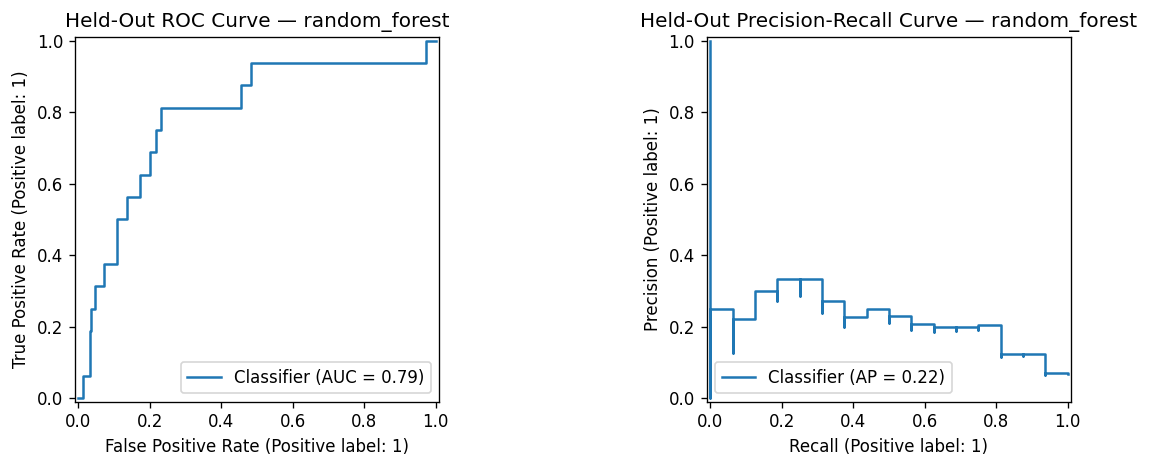

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[0])
axes[0].set_title(f"Held-Out ROC Curve — {winner}")
PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[1])
axes[1].set_title(f"Held-Out Precision-Recall Curve — {winner}")
plt.tight_layout()

At its frozen threshold the selected random_forest catches 13 of 16 failing wafers and leaves 3 failure escapes, at the cost of 53 unnecessary-review false fails. Because the configured false-pass cost is ten times the false-fail cost, the threshold analysis below — not the default 0.5 operating point — is the relevant view of the model as a decision-support component.

## Cost-Sensitive Threshold Behavior

The cost curve evaluates the selected model's probability scores under the configured false-pass and false-fail penalties. The red line marks the **frozen threshold of 0.14** — derived from training out-of-fold predictions, not tuned on this curve — which sits far below the default 0.5 and shifts the model toward catching more failures at the expense of more false-fail review load. The printed comparison shows the expected-cost improvement over the default operating point.

Default-threshold (0.5) expected cost: 160.0
Frozen threshold 0.140 expected cost: 83.0


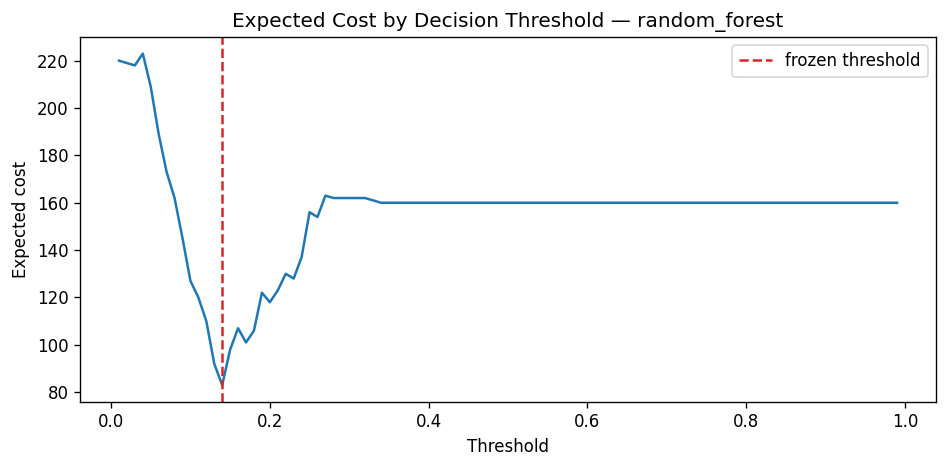

In [9]:
cost_curve = threshold_cost_curve(
    y_test, y_prob, cost_cfg.cost_matrix, cost_cfg.threshold_search
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(cost_curve["threshold"], cost_curve["expected_cost"])
ax.axvline(frozen, color="tab:red", linestyle="--", label="frozen threshold")
ax.set_title(f"Expected Cost by Decision Threshold — {winner}")
ax.set_xlabel("Threshold")
ax.set_ylabel("Expected cost")
ax.legend()
plt.tight_layout()

default_metrics = compute_metrics(y_test, y_prob, threshold=0.5)
default_cm = default_metrics.confusion_matrix
default_cost = (
    default_cm[1][0] * cost_cfg.cost_matrix.false_pass
    + default_cm[0][1] * cost_cfg.cost_matrix.false_fail
)

print(f"Default-threshold (0.5) expected cost: {default_cost:.1f}")
print(
    f"Frozen threshold {frozen:.3f} expected cost: "
    f"{expected_cost:.1f}"
)

The frozen threshold of 0.14 trades unnecessary review load for fewer failure escapes, and reduces the configured expected cost relative to the default 0.5 operating point. Empirically the selected model is more useful as a high-recall screening aid than as a balanced classifier — which is exactly what the cost matrix is designed to reward.

## Feature Importance

`extract_feature_importance` reads importance from the winning pipeline regardless of family: native `feature_importances_` for tree models, signed coefficients for linear models, both normalized to a uniform `feature` / `importance` / `abs_importance` schema. Because the winner is `random_forest`, the values are non-negative impurity-based importances over the columns the preprocessor retained.

The leading sensors are `sensor_059`, `sensor_033`, `sensor_103`, `sensor_130`, and `sensor_129`. These identify where the model concentrates its split signal and give engineering teams a focused sensor list for follow-up. The SHAP analysis in notebook 05 checks whether the same sensors dominate attribution from a different method.

Saved feature importance to C:\Users\Virgil\Code\semiconductor-yield-root-cause\reports\feature_importance.csv


,feature,importance,abs_importance
0,sensor_059,0.030498,0.030498
1,sensor_033,0.022407,0.022407
2,sensor_103,0.020083,0.020083
3,sensor_130,0.016214,0.016214
4,sensor_129,0.015380,0.015380
5,sensor_031,0.013752,0.013752
6,sensor_510,0.012441,0.012441
7,sensor_021,0.011433,0.011433
8,sensor_205,0.011409,0.011409
9,sensor_125,0.010506,0.010506


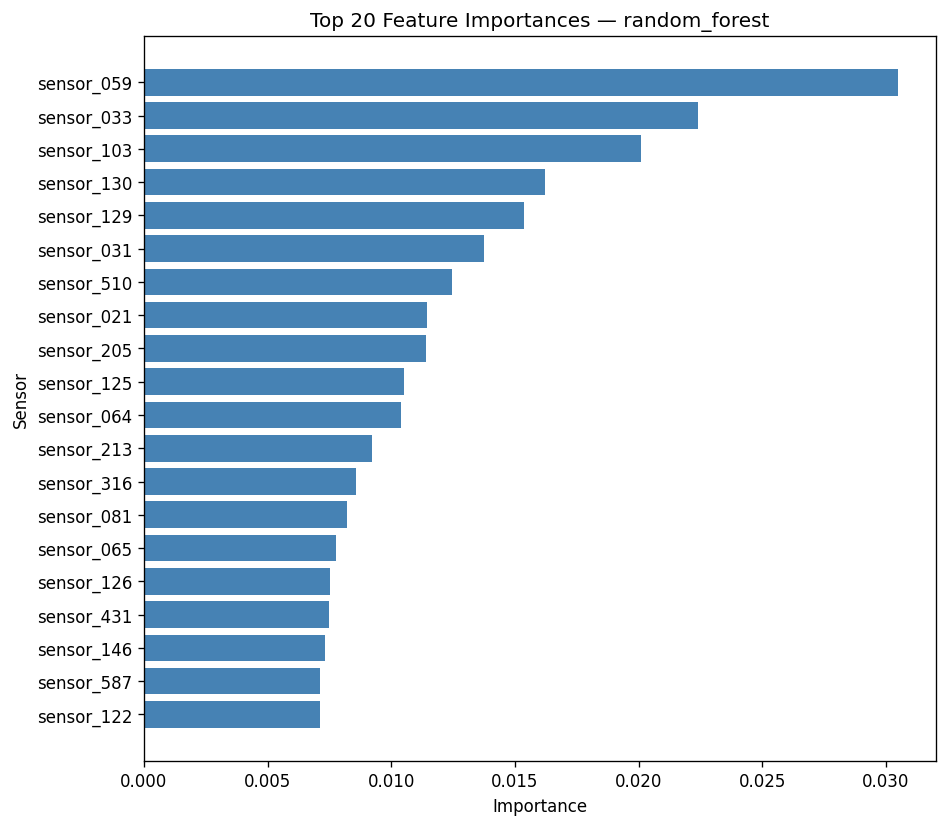

In [10]:
# The classifier sees only the columns SecomPreprocessor kept, so importance
# is reported against the fitted feature names, not the raw sensor list.
feature_names = model_feature_names(pipeline)
importance_df = extract_feature_importance(pipeline, feature_names)

importance_path = reports_dir / "feature_importance.csv"
importance_df.to_csv(importance_path, index=False)

figures_dir.mkdir(parents=True, exist_ok=True)
plot_top_features(
    importance_df,
    top_n=20,
    output_path=figures_dir / "feature_importance.png",
    value_column="importance",
)

top_n = 20
top_features = importance_df.head(top_n).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top_features["feature"], top_features["importance"], color="steelblue")
ax.set_title(f"Top {top_n} Feature Importances — {winner}")
ax.set_xlabel("Importance")
ax.set_ylabel("Sensor")
plt.tight_layout()

print(f"Saved feature importance to {importance_path}")
importance_df.head(10)

## CV vs Test Ranking

Under this configuration the cross-validation and held-out rankings agree: `random_forest` has both the highest CV PR-AUC (0.227) and the highest test PR-AUC (0.222), so the family chosen before the test set was opened is also the strongest on it. `xgboost` is the nearest challenger on both views (CV 0.198, test 0.213), and the two overlap well within one CV standard-deviation band; ROC-AUC tells the same story (0.793 vs 0.786). `logistic_regression` trails both tree families but stays well clear of the `dummy` floor.

This is the comfortable case for the selection protocol — the winner is fixed on cross-validation alone and the test set is scored exactly once afterward, and here that single look confirms rather than contradicts the choice. The agreement should still be read cautiously: with only 16 positives in the test split, fold-to-fold and split-to-split PR-AUC are volatile. If the random_forest/xgboost gap proved unstable across additional splits or a larger positive sample, the next step would be repeated or higher-fold cross-validation to tighten the estimate before committing to a family.

## Modeling Assessment

The four-family comparison shows real but limited predictive signal. The selected random_forest separates failures better than chance on the held-out set (ROC-AUC 0.793), while PR-AUC stays low (0.222) and precision is modest. At its cost-tuned threshold the model reaches high recall (0.81), catching 13 of 16 failures at the price of a heavy false-fail review load. The cost-sensitive operating point improves the configured business objective by reducing failure escapes, so the selected model is useful for prioritizing engineering review rather than serving as a fully automated release gate. Notebook 05 takes the persisted `selected_model.joblib` forward into SHAP-based root-cause analysis.